<a href="https://colab.research.google.com/github/juanmorales2993/Ayudantias/blob/main/Ayudantia_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ayudantía 4: Generalización, Regularización y Métricas de Clasificación**

**Curso:** Aplicaciones de Machine Learning en Economía

**Ayudantes:**
- Maykol Medrano -- mmedrano2@uc.cl
- Pablo Acevedo -- jbvillagra@uc.cl

### **Contenidos**

1. **Generalización** — cómo saber si nuestro modelo realmente aprendió o solo memorizó los datos?
2. **Regularización (Ridge, Lasso, ElasticNet)** — restringir los coeficientes para evitar overfitting.
3. **Métricas de clasificación** — Accuracy, Precision, Recall, F1, Matriz de Confusión, ROC-AUC.

**Como lo haremos?** Usaremos dos problemas económicos reales:
- **Regresión:** predicción de precios de vivienda (California Housing).
- **Clasificación:** predicción de default crediticio (datos sintéticos inspirados en score bancario).

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, roc_auc_score
)
from sklearn.tree import DecisionTreeClassifier

# Semilla para reproducibilidad
np.random.seed(42)

# No filtraremos los warnings
# En la seccion de regularizacion veremos por que a veces conviene NO filtrarlos
#import warnings
#warnings.filterwarnings("ignore")

---

## **1. Generalización: Overfitting, Underfitting y el Bias-Variance Tradeoff**

En econometría, cuando ajustamos un modelo nos importa la **inferencia causal**: cuál es el efecto de $X$ sobre $Y$? En ML, la pregunta central es distinta: **qué tan bien predice mi modelo datos que nunca ha visto?** Esta capacidad se llama **generalización**.

Imaginemos que los analistas de LATAM construyen un modelo para predecir la demanda de carga en el futuro dado que deben decidir si los 767-300ER utilizados para transporte de pasajeros, serán dados de baja definitivamente o si se someterán al proceso de conversión a la variente CARGO. Si el modelo se ajusta perfectamente a los datos históricos (2010-2023) pero falla estrepitosamente prediciendo 2024 y 2025, decimos que **memorizó** los datos — no **aprendió** el patrón subyacente. Eso es **overfitting**.

- **Capacidad del modelo:** qué tan complejo puede ser el patrón que captura. Un polinomio de grado 9 tiene más capacidad que uno de grado 1.
- **Overfitting:** el modelo memorizó el ruido del training set. `CAPACIDAD > COMPLEJIDAD del problema`.
- **Underfitting:** el modelo es demasiado simple para capturar la relación real. `CAPACIDAD < COMPLEJIDAD del problema`.

#### **1.1 Ejemplo: Ajuste polinomial a datos económicos simulados**

Simulemos un proceso generador de datos (DGP por su sigla en inglés) donde la relación verdadera entre $X$ e $Y$ es un polinomio de grado 3 con ruido:

$$y = 0.5x^3 - 2x^2 + x + 3 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

Ajustaremos polinomios de distintos grados para ver ejemplos de overfitting y underfitting.

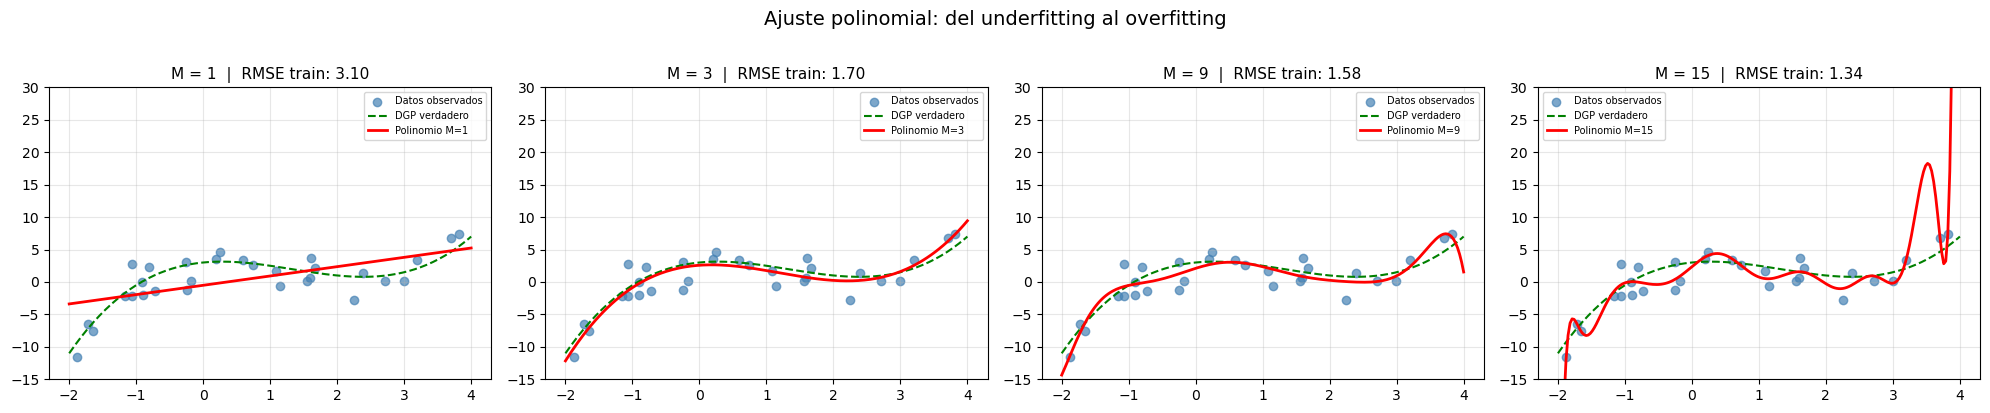

In [ ]:
# Generamos datos sinteticos con DGP conocido
# La relacion verdadera es un polinomio de grado 3
n_obs = 30
X_sim = np.sort(np.random.uniform(-2, 4, n_obs))
y_verdadera = 0.5 * X_sim**3 - 2 * X_sim**2 + X_sim + 3
y_sim = y_verdadera + np.random.normal(0, 2, n_obs)

# Curva verdadera para graficar
X_plot = np.linspace(-2, 4, 200)
y_plot_verdadera = 0.5 * X_plot**3 - 2 * X_plot**2 + X_plot + 3

# Ajustamos polinomios de grado 1, 3, 9 y 15
grados = [1, 3, 9, 15]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, grado in enumerate(grados):
    coefs = np.polyfit(X_sim, y_sim, grado)
    y_pred_plot = np.polyval(coefs, X_plot)
    y_pred_train = np.polyval(coefs, X_sim)
    rmse_train = np.sqrt(mean_squared_error(y_sim, y_pred_train))

    axes[i].scatter(X_sim, y_sim, color="steelblue", alpha=0.7, label="Datos observados")
    axes[i].plot(X_plot, y_plot_verdadera, "g--", linewidth=1.5, label="DGP verdadero")
    axes[i].plot(X_plot, y_pred_plot, "r-", linewidth=2, label=f"Polinomio M={grado}")
    axes[i].set_ylim(-15, 30)
    axes[i].set_title(f"M = {grado}  |  RMSE train: {rmse_train:.2f}", fontsize=11)
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Ajuste polinomial: del underfitting al overfitting", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- **M=1 (underfitting):** la recta no captura la curvatura del DGP. El modelo es demasiado simple.
- **M=3 (ajuste adecuado):** captura la esencia de la relación cúbica sin perseguir el ruido.
- **M=9 y M=15 (overfitting):** el polinomio pasa cerca de cada punto, pero se mueve mucho entre ellos. Memorizó el ruido.

> el RMSE de entrenamiento **siempre** baja al incrementar la capacidad. Eso no significa que el modelo sea mejor! Lo que importa es el error sobre datos **no vistos**.

#### **1.2 Cuantificando el overfitting: Error de Train vs. Test**

Para detectar overfitting necesitamos comparar el error en datos de entrenamiento versus datos que el modelo **nunca** vio. Si la brecha es grande, el modelo está memorizando.

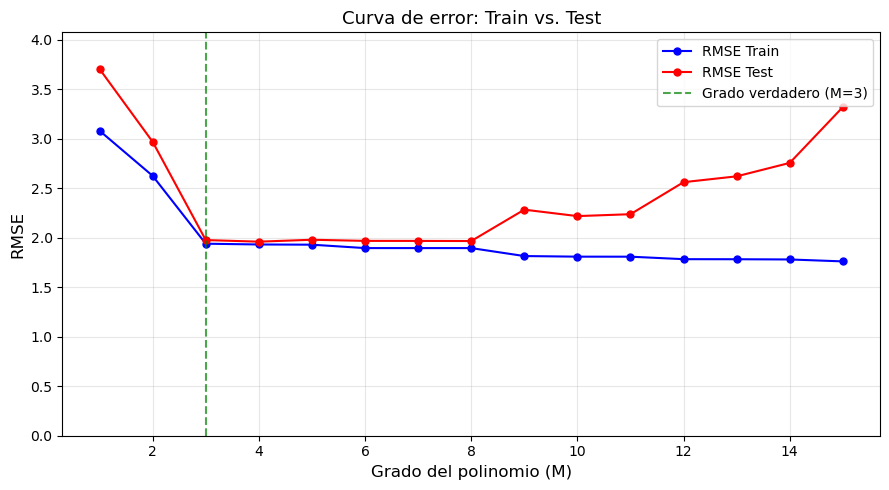

M= 1    RMSE Train: 3.083    RMSE Test: 3.706    Diferencia: 0.624
M= 3    RMSE Train: 1.941    RMSE Test: 1.978    Diferencia: 0.037
M= 5    RMSE Train: 1.931    RMSE Test: 1.981    Diferencia: 0.050
M= 9    RMSE Train: 1.816    RMSE Test: 2.285    Diferencia: 0.469
M=15    RMSE Train: 1.762    RMSE Test: 3.322    Diferencia: 1.560


In [ ]:
# Generamos un dataset mas grande y lo particionamos
n_total = 100
X_full = np.sort(np.random.uniform(-2, 4, n_total))
y_full = 0.5 * X_full**3 - 2 * X_full**2 + X_full + 3 + np.random.normal(0, 2, n_total)

# 70% entrenamiento, 30% test
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42
)

# Evaluamos RMSE en train y test para cada grado de polinomio
grados_eval = range(1, 16)
rmse_train_list = []
rmse_test_list = []

for grado in grados_eval:
    coefs = np.polyfit(X_train_s, y_train_s, grado)
    y_pred_tr = np.polyval(coefs, X_train_s)
    y_pred_te = np.polyval(coefs, X_test_s)
    rmse_train_list.append(np.sqrt(mean_squared_error(y_train_s, y_pred_tr)))
    rmse_test_list.append(np.sqrt(mean_squared_error(y_test_s, y_pred_te)))

# Grafico de curvas de error
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(grados_eval), rmse_train_list, "b-o", label="RMSE Train", markersize=5)
ax.plot(list(grados_eval), rmse_test_list, "r-o", label="RMSE Test", markersize=5)
ax.axvline(x=3, color="green", linestyle="--", alpha=0.7, label="Grado verdadero (M=3)")
ax.set_xlabel("Grado del polinomio (M)", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_title("Curva de error: Train vs. Test", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, max(rmse_test_list) * 1.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen de grados relevantes
for g in [1, 3, 5, 9, 15]:
    idx = g - 1
    print(f"M={g:>2d}    RMSE Train: {rmse_train_list[idx]:.3f}    RMSE Test: {rmse_test_list[idx]:.3f}    Diferencia: {rmse_test_list[idx] - rmse_train_list[idx]:.3f}")

- El **RMSE de entrenamiento** siempre disminuye al aumentar $M$ (más capacidad = mejor ajuste a los datos vistos).
- El **RMSE de test** primero baja y luego sube — la clásica forma de "U".
- El **punto óptimo** está cerca de $M=3$, que coincide con el DGP verdadero.
- La **brecha** entre train y test crece al aumentar $M$ — esa brecha **es** el overfitting.

En la práctica no conocemos el DGP. Por eso usamos **Cross Validation** (visto en la Ayudantía 3) para estimar el error de generalización sin tocar el test set.

#### **1.3 El Bias-Variance Tradeoff**

La curva de error que acabamos de ver refleja un dilema fundamental:

- **Bias (sesgo):** error por simplificar demasiado. Un modelo $M=1$ tiene alto bias — asume que la relación es lineal cuando no lo es.
- **Variance (varianza):** error por ser demasiado sensible a los datos de entrenamiento. Un modelo $M=15$ tiene alta varianza — cambia drásticamente si cambian los datos.

$$\text{Error total} = \text{Bias}^2 + \text{Variance} + \text{Ruido irreducible}$$


**A modo de ejemplo:** es como la estimación de un modelo de inflación en el Banco Central. Un AR(1) tiene alto bias (ignora variables relevantes como expectativas, tipo de cambio, etc.). Un modelo con 200 regresores macro tiene alta varianza (se ajusta al ruido y las proyecciones fuera de muestra serán malas). El "arte" es encontrar el punto medio.

> En la **práctica**, no podemos medir bias y varianza por separado (necesitaríamos conocer el DGP verdadero). Por eso usamos **Cross Validation**: es nuestra mejor herramienta para aproximar el punto óptimo en la curva.

---

## **2. Regularización: Ridge, Lasso y ElasticNet**

Consiste en agregar un **término de penalización** a la función de pérdida que castiga coeficientes grandes:

#### **Ejemplo con Stata**

En Stata, cuando ejecutamos `regress y x1 x2 ... x50`, se minimiza $\sum (y_i - \hat{y}_i)^2$ sin restricciones. Si tenemos muchas variables, algunos coeficientes pueden volverse gigantescos para ajustar ruido. Regularizar es como decirle al modelo: "minimiza el error, **PERO** los coeficientes no pueden ser demasiado grandes".

La función de pérdida de OLS es:

$$\mathcal{L}_{OLS} = \frac{1}{2N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

La regularización agrega un término de penalización ponderado por $\lambda \geq 0$:

| Método | Función de pérdida | Penalización |
|---|---|---|
| **Ridge (L2)** | $\mathcal{L}_{OLS} + \lambda \sum_{j=1}^{p} w_j^2$ | Cuadrado de los coeficientes |
| **Lasso (L1)** | $\mathcal{L}_{OLS} + \lambda \sum_{j=1}^{p} \|w_j\|$ | Valor absoluto |
| **ElasticNet** | $\mathcal{L}_{OLS} + \lambda_1 \sum \|w_j\| + \lambda_2 \sum w_j^2$ | Combinación L1 + L2 |

**Diferencias entre Ridge y Lasso:**
- **Ridge** encoge los coeficientes hacia cero, pero nunca los lleva **exactamente** a cero.
- **Lasso** puede llevar coeficientes exactamente a cero -> funciona como **selección de variables**.
- En economía, Lasso es útil cuando sospechamos que solo un subconjunto de las $p$ variables es relevante. Por ejemplo, puede ser útil para seleccionar las variables que mejor representen las caracteristicas físicas de un hogar desde la CASEN (hay muchas variables que asociadas al hogar, por ejemplo tipo de piso, material de construcción, etc...).

#### **2.1 Aplicación: Predicción de precios de vivienda con California Housing**

Utilizaremos datos derivados del censo de 1990 en EEUU. En el dataset, cada fila representa un bloque censal, los cuales corresponden a la unidad geográfica mínima bajo la cual la oficina censal americana publica información (cada bloque tiene una población en el rango 600-3000 personas).

In [ ]:
# Cargamos California Housing
# Pueden encontrar la documentacion del dataset aca
# https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset
housing = datasets.fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = housing.target

print(f"Dimensión df: {X_housing.shape[0]:,} observaciones, {X_housing.shape[1]} variables")
print(f"Variable objetivo: Mediana del valor de la vivienda por bloque censal (en USD 100k)")
X_housing.head()

Dimensión df: 20,640 observaciones, 8 variables
Variable objetivo: Mediana del valor de la vivienda por bloque censal (en USD 100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# IMPORTANTE!!!
# Tenemos que estandarizar las features
# Si no estandarizamos, variables con escalas grandes reciben penalizacion desproporcionada
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]:,} obs  |  Test: {X_test_sc.shape[0]:,} obs")

Train: 16,512 obs  |  Test: 4,128 obs


> **RECUERDEN:** Para regularización, **siempre** debemos estandarizar las variables antes de entrenar. Si no lo hacemos, una variable medida en millones (como `Population`) recibirá una penalización mucho mayor que una medida en unidades (como `AveRooms`), simplemente por su escala.

In [ ]:
# Comparamos OLS, Ridge, Lasso y ElasticNet
# alpha en sklearn corresponde al lambda de la definicion de la penalización

modelos = {
    "OLS (sin regularizacion)": LinearRegression(),
    "Ridge (L2, alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (L1, alpha=0.01)": Lasso(alpha=0.01),
    "ElasticNet (L1+L2)": ElasticNet(alpha=0.01, l1_ratio=0.5),
}

resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    y_pred_tr = modelo.predict(X_train_sc)
    y_pred_te = modelo.predict(X_test_sc)

    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_te))
    r2_te = r2_score(y_test, y_pred_te)

    resultados.append({
        "Modelo": nombre,
        "RMSE Train": rmse_tr,
        "RMSE Test": rmse_te,
        "R2 Test": r2_te,
        "Diferencia": rmse_te - rmse_tr
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False, float_format="{:.4f}".format))

                  Modelo  RMSE Train  RMSE Test  R2 Test  Diferencia
OLS (sin regularizacion)      0.7197     0.7456   0.5758      0.0259
   Ridge (L2, alpha=1.0)      0.7197     0.7456   0.5758      0.0259
  Lasso (L1, alpha=0.01)      0.7235     0.7404   0.5816      0.0170
      ElasticNet (L1+L2)      0.7219     0.7416   0.5803      0.0197


Con solo 8 features y 20k observaciones, OLS ya generaliza bien (poca diferencia train-test). La regularización destaca cuando tenemos **muchas features relativas a las observaciones** ($p \gg N$) o **alta colinealidad**. Veámoslo creando features polinomiales artificiales.

In [ ]:
# Creamos interacciones y terminos cuadraticos para aumentar p
# Esto genera 44 features a partir de 8 (incluyendo interacciones)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_sc)
X_test_poly = poly.transform(X_test_sc)

print(f"Features originales: {X_train_sc.shape[1]}")
print(f"Features polinomiales: {X_train_poly.shape[1]}")

Features originales: 8
Features polinomiales: 44


In [ ]:
# Ahora la comparacion es mas interesante con 44 features
modelos_poly = {
    "OLS": LinearRegression(),
    "Ridge (alpha=1)": Ridge(alpha=1.0),
    "Ridge (alpha=10)": Ridge(alpha=10.0),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01, selection='random', tol=1e-3, max_iter=1000),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1, selection='random', tol=1e-3, max_iter=1000),
    "Lasso (alpha=0.2)": Lasso(alpha=0.2, selection='random', tol=1e-3, max_iter=1000),
    "ElasticNet (alpha=0.1, l1_ratio=0.5)": ElasticNet(alpha=0.1, l1_ratio=0.5, selection='random', tol=1e-3, max_iter=1000),
}

resultados_poly = []

for nombre, modelo in modelos_poly.items():
    modelo.fit(X_train_poly, y_train)
    y_pred_tr = modelo.predict(X_train_poly)
    y_pred_te = modelo.predict(X_test_poly)

    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test, y_pred_te))

    # Contamos coeficientes que Lasso llevo a cero
    n_ceros = np.sum(np.abs(modelo.coef_) < 1e-10) if hasattr(modelo, "coef_") else 0

    resultados_poly.append({
        "Modelo": nombre,
        "RMSE Train": rmse_tr,
        "RMSE Test": rmse_te,
        "Diferencia": rmse_te - rmse_tr,
        "Coefs = 0": n_ceros
    })

df_res_poly = pd.DataFrame(resultados_poly)
print(df_res_poly.to_string(index=False, float_format="{:.4f}".format))

/opt/homebrew/Caskroom/miniconda/base/envs/python314/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.266e+02, tolerance: 2.207e+01
  model = cd_fast.enet_coordinate_descent(


                              Modelo  RMSE Train  RMSE Test  Diferencia  Coefs = 0
                                 OLS      0.6486     0.6814      0.0328          0
                     Ridge (alpha=1)      0.6486     0.6802      0.0316          0
                    Ridge (alpha=10)      0.6489     0.6715      0.0226          0
                  Lasso (alpha=0.01)      0.7027     0.7855      0.0827         16
                   Lasso (alpha=0.1)      0.8168     0.8237      0.0069         38
                   Lasso (alpha=0.2)      0.8590     0.8624      0.0034         41
ElasticNet (alpha=0.1, l1_ratio=0.5)      0.7905     0.7970      0.0065         35


- Lasso lleva varios coeficientes a exactamente cero — está haciendo **selección de variables automática**.
- Ridge no elimina variables, pero encoge todos los coeficientes.
- ElasticNet combina ambas propiedades.

**MUY IMPORTANTE**

Si suprimen los warnings, podrian no percatarse de advertencias que podrían ser relevantes, en este caso, si alpha=0.01, la función de perdida no converge y el error incluso sugiere que se debe utilizar una regularización mayor!

#### **2.2 El efecto de $\lambda$ sobre los coeficientes (Regularization Path)**

Veamos gráficamente cómo los coeficientes se encogen a medida que aumentamos $\lambda$ (el parámetro `alpha` en `scikit-learn`).

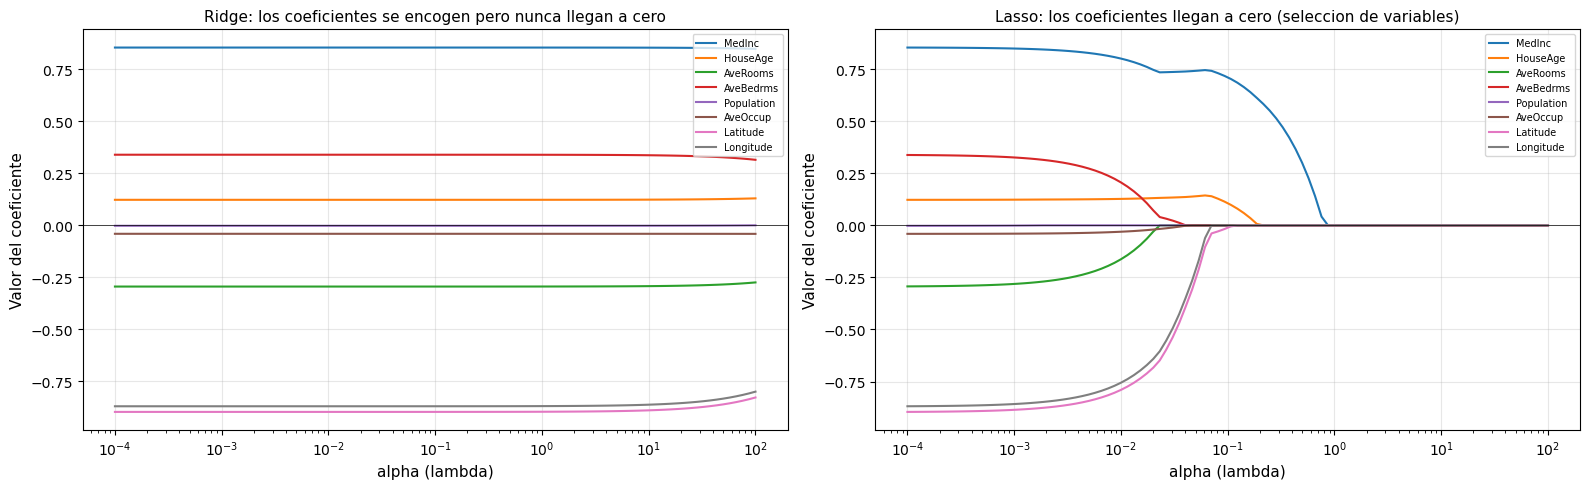

In [ ]:
# Regularization path: como cambian los coeficientes al variar alpha
alphas = np.logspace(-4, 2, 100)
coefs_ridge = []
coefs_lasso = []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_sc, y_train)
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_train_sc, y_train)
    coefs_ridge.append(ridge.coef_)
    coefs_lasso.append(lasso.coef_)

coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

# Si el tamaño de los gráficos se muy grande, pueden ajustar el figsize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ridge path
for j in range(coefs_ridge.shape[1]):
    axes[0].plot(alphas, coefs_ridge[:, j], label=housing.feature_names[j])
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha (lambda)", fontsize=11)
axes[0].set_ylabel("Valor del coeficiente", fontsize=11)
axes[0].set_title("Ridge: los coeficientes se encogen pero nunca llegan a cero", fontsize=11)
axes[0].legend(fontsize=7, loc="upper right")
axes[0].axhline(y=0, color="black", linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# Lasso path
for j in range(coefs_lasso.shape[1]):
    axes[1].plot(alphas, coefs_lasso[:, j], label=housing.feature_names[j])
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (lambda)", fontsize=11)
axes[1].set_ylabel("Valor del coeficiente", fontsize=11)
axes[1].set_title("Lasso: los coeficientes llegan a cero (seleccion de variables)", fontsize=11)
axes[1].legend(fontsize=7, loc="upper right")
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Como interpretar los gráficos:**
- **Eje X:** Magnitud de la regularización ($\lambda$). A la izquierda $\lambda \approx 0$ (sin penalización = OLS), a la derecha $\lambda$ grande (penalización cada vez mayor).
- **Ridge (gráfico de la izquierda):** los coeficientes se acercan a cero suavemente.
- **Lasso (gráfico de la derecha):** los coeficientes se hacen cero uno a uno. Las variables más relevantes (como `MedInc`) son las últimas en desaparecer.

> Notar que `MedInc` (mediana del ingreso por bloque censal) es consistentemente la variable más importante. Esto tiene sentido económico: el ingreso del distrito es el mejor predictor del valor de la vivienda.

#### **2.3 Selección de $\lambda$ óptimo con Cross Validation**

El valor de $\lambda$ es un **hiperparámetro** que debemos elegir, pero como lo hacemos? Con Cross Validation (CV).

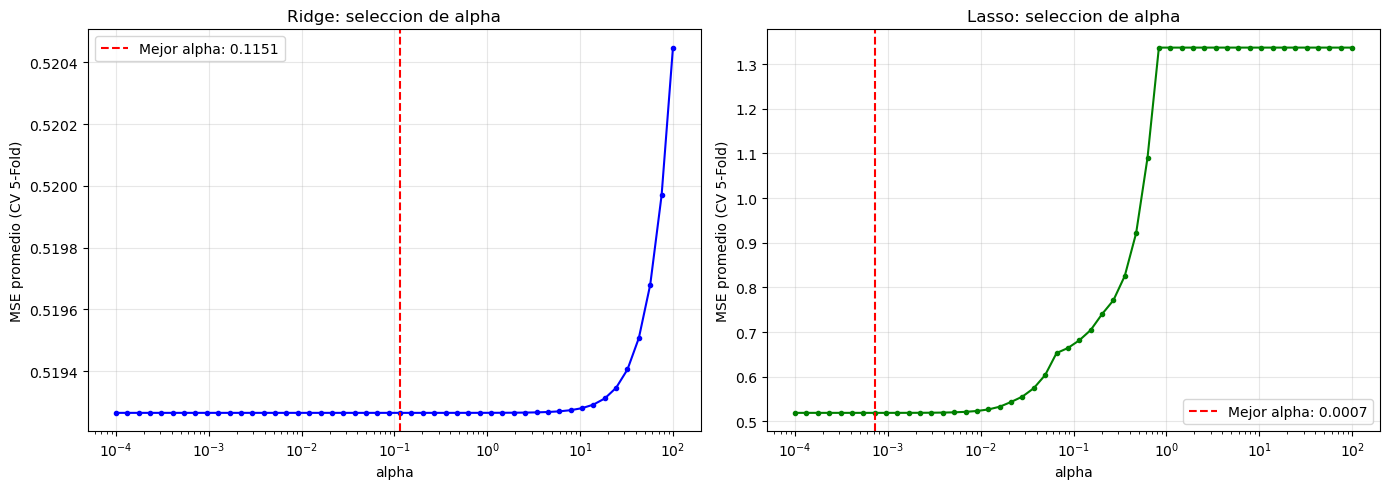

Alpha optimo Ridge: 0.1151
Alpha optimo Lasso: 0.0007


In [ ]:
# Buscamos el alpha optimo para Ridge y Lasso via CV
alphas_cv = np.logspace(-4, 2, 50)

cv_scores_ridge = []
cv_scores_lasso = []

for a in alphas_cv:
    score_r = cross_val_score(Ridge(alpha=a), X_train_sc, y_train,
                              cv=5, scoring="neg_mean_squared_error").mean()
    score_l = cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_sc, y_train,
                              cv=5, scoring="neg_mean_squared_error").mean()
    cv_scores_ridge.append(-score_r)
    cv_scores_lasso.append(-score_l)

# Mejor alpha
best_alpha_ridge = alphas_cv[np.argmin(cv_scores_ridge)]
best_alpha_lasso = alphas_cv[np.argmin(cv_scores_lasso)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alphas_cv, cv_scores_ridge, "b-o", markersize=3)
axes[0].axvline(x=best_alpha_ridge, color="red", linestyle="--", label=f"Mejor alpha: {best_alpha_ridge:.4f}")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("MSE promedio (CV 5-Fold)")
axes[0].set_title("Ridge: seleccion de alpha")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas_cv, cv_scores_lasso, "g-o", markersize=3)
axes[1].axvline(x=best_alpha_lasso, color="red", linestyle="--", label=f"Mejor alpha: {best_alpha_lasso:.4f}")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("MSE promedio (CV 5-Fold)")
axes[1].set_title("Lasso: seleccion de alpha")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Alpha optimo Ridge: {best_alpha_ridge:.4f}")
print(f"Alpha optimo Lasso: {best_alpha_lasso:.4f}")

#### **2.4 Atajo: `RidgeCV` y `LassoCV`**

El proceso que acabamos de hacer manualmente (iterar sobre alphas, calcular CV, encontrar el mínimo) es tan común que `sklearn` tiene funciones que lo hacen automáticamente:

In [ ]:
# RidgeCV y LassoCV hacen el grid search + CV internamente
from sklearn.linear_model import RidgeCV, LassoCV

ridge_auto = RidgeCV(alphas=np.logspace(-4, 2, 50), cv=5)
ridge_auto.fit(X_train_sc, y_train)

lasso_auto = LassoCV(alphas=np.logspace(-4, 2, 50), cv=5, max_iter=10000)
lasso_auto.fit(X_train_sc, y_train)

print(f"RidgeCV -> alpha optimo: {ridge_auto.alpha_:.4f}")
print(f"LassoCV -> alpha optimo: {lasso_auto.alpha_:.4f}")

# Estos valores deberian coincidir con los que encontramos manualmente. En la practica, usar RidgeCV/LassoCV es mas eficiente y menos propenso a errores.

RidgeCV -> alpha optimo: 0.0001
LassoCV -> alpha optimo: 0.0007


---

## **3. Métricas de Performance en Clasificación**

Hasta ahora solo hemos visto ejemplos con variables continuas, los cuales hemos abordado con **regresiones**. A continuación trabajaremos con variables categóricas, para las que tendremos que usar **clasificadores**. En este caso la variable objetivo toma valores discretos:

$$y \in \{0, 1\} \quad \text{(clasificación binaria)}$$

#### **Predicción de default crediticio**

Un banco necesita decidir si otorga un crédito a un solicitante. El modelo debe predecir si el cliente caerá en **default** ($y=1$) o no ($y=0$). Las métricas de evaluación son cruciales aquí porque los errores **no son simétricos**:

- **Aprobar a alguien que hará default** (Falso Negativo) -> el banco pierde dinero.
- **Rechazar a alguien que pagaría** (Falso Positivo) -> el banco pierde un buen cliente.

#### **3.1 Datos simulados de score crediticio**

In [ ]:
# Simulamos datos de score crediticio
# Escenario: 5000 solicitudes de credito con 15% de tasa de default
n_creditos = 5000

# Variables del solicitante
ingreso_mensual = np.random.lognormal(mean=13.5, sigma=0.6, size=n_creditos)  # CLP
edad = np.random.normal(40, 12, n_creditos).clip(22, 70).astype(int)
ratio_deuda_ingreso = np.random.beta(2, 5, n_creditos)  # entre 0 y 1
meses_empleo = np.random.exponential(36, n_creditos).clip(1, 360).astype(int)
n_creditos_previos = np.random.poisson(3, n_creditos)
monto_solicitado = np.random.lognormal(mean=15, sigma=0.8, size=n_creditos)

# Probabilidad de default (DGP conocido)
# Mayor deuda/ingreso y menor ingreso aumentan la probabilidad de default
logit = (
    -3.0
    + 4.0 * ratio_deuda_ingreso
    - 0.5 * np.log(ingreso_mensual / 1e6)
    - 0.02 * meses_empleo
    + 0.3 * (monto_solicitado / ingreso_mensual)
    + np.random.normal(0, 0.5, n_creditos)
)
prob_default = 1 / (1 + np.exp(-logit))
default = (np.random.uniform(size=n_creditos) < prob_default).astype(int)

# Construimos el DataFrame
df_credit = pd.DataFrame({
    "ingreso_mensual": ingreso_mensual.astype(int),
    "edad": edad,
    "ratio_deuda_ingreso": ratio_deuda_ingreso.round(3),
    "meses_empleo": meses_empleo,
    "n_creditos_previos": n_creditos_previos,
    "monto_solicitado": monto_solicitado.astype(int),
    "default": default
})

print(f"Observaciones: {len(df_credit):,}")
print(f"Tasa de default: {default.mean():.1%}")
print()
df_credit.head(10)

Observaciones: 5,000
Tasa de default: 40.5%



,ingreso_mensual,edad,ratio_deuda_ingreso,meses_empleo,n_creditos_previos,monto_solicitado,default
0,1168954,31,0.192,21,1,2450433,0
1,613978,49,0.043,35,1,3652499,0
2,582569,51,0.088,35,6,4879538,0
3,446321,39,0.086,26,4,4371473,0
4,501248,26,0.426,14,7,3118816,1
5,618983,61,0.370,39,7,4226760,0
6,2370358,29,0.218,65,2,1023986,0
7,648013,22,0.168,6,3,1174341,1
8,349538,22,0.598,14,1,1345080,1
9,747881,41,0.177,39,2,3299227,0


In [ ]:
# Preparamos los datos para clasificacion
X_credit = df_credit.drop(columns="default")
y_credit = df_credit["default"]

# Es importante usar stratify=y_credit para mantener la proporcion de default en ambos sets!!!
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit
)

# Estandarizamos
scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc = scaler_c.transform(X_test_c)

print(f"Train: {len(y_train_c):,} obs  (default: {y_train_c.mean():.1%})")
print(f"Test:  {len(y_test_c):,} obs  (default: {y_test_c.mean():.1%})")

Train: 4,000 obs  (default: 40.5%)
Test:  1,000 obs  (default: 40.5%)


#### **3.2 Entrenando un clasificador y obteniendo predicciones**

Usaremos **Regresión Logística** — el análogo de clasificación a la regresión lineal. En Stata sería `logit default ingreso_mensual edad ...`.

In [ ]:
# Entrenamos una regresion logistica
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_c_sc, y_train_c)

# Predicciones de clase (0 o 1) y de probabilidad
y_pred_c = log_reg.predict(X_test_c_sc)
y_prob_c = log_reg.predict_proba(X_test_c_sc)[:, 1]  # probabilidad de default

print("Primeras 10 predicciones:")
print(f"{'Real':>6} {'Pred':>6} {'P(default)':>12}")
for i in range(10):
    print(f"{y_test_c.iloc[i]:>6d} {y_pred_c[i]:>6d} {y_prob_c[i]:>12.3f}")

Primeras 10 predicciones:
  Real   Pred   P(default)
     0      0        0.022
     1      0        0.315
     0      0        0.341
     0      0        0.091
     1      1        0.930
     1      1        0.689
     1      1        0.804
     1      0        0.471
     0      0        0.097
     1      0        0.416


#### **3.3 La Matriz de Confusión**

La **matriz de confusión** es fundamental para entender y evaluar el desempeño del clasificador. Organiza las predicciones en 4 categorías:

| | Predicho: No Default (0) | Predicho: Default (1) |
|---|---|---|
| **Real: No Default (0)** | True Negative (TN) | False Positive (FP) |
| **Real: Default (1)** | False Negative (FN) | True Positive (TP) |

- **TN:** correctamente identificamos a un buen pagador -> le damos crédito.
- **TP:** correctamente identificamos a alguien que hará default -> le negamos crédito.
- **FP (Error Tipo I):** etiquetamos como moroso a alguien que pagaría -> perdemos un cliente.
- **FN (Error Tipo II):** aprobamos a alguien que hará default -> el banco pierde dinero.

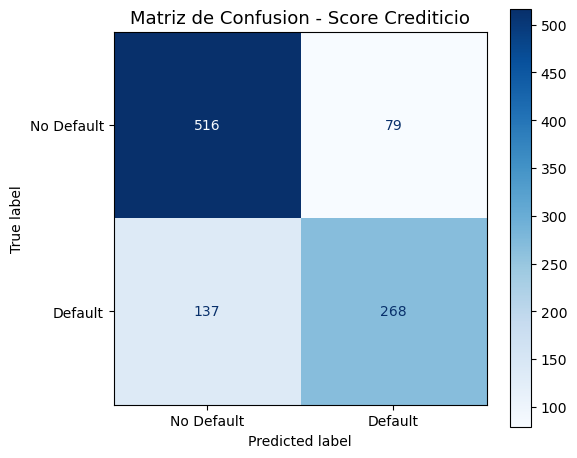

Verdaderos Negativos (TN): 516 -- buenos pagadores predichos correctamente
Falsos Positivos (FP):     79 -- buenos pagadores predichos como morosos (Error Tipo I)
Falsos Negativos (FN):     137 -- morosos predichos como buenos pagadores (Error Tipo II)
Verdaderos Positivos (TP): 268 -- morosos predichos correctamente


In [ ]:
# Matriz de confusion
cm = confusion_matrix(y_test_c, y_pred_c)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Matriz de Confusion - Score Crediticio", fontsize=13)
plt.tight_layout()
plt.show()

# Extraemos los valores
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn} -- buenos pagadores predichos correctamente")
print(f"Falsos Positivos (FP):     {fp} -- buenos pagadores predichos como morosos (Error Tipo I)")
print(f"Falsos Negativos (FN):     {fn} -- morosos predichos como buenos pagadores (Error Tipo II)")
print(f"Verdaderos Positivos (TP): {tp} -- morosos predichos correctamente")

#### **3.4 Métricas derivadas de la Matriz de Confusión**

A partir de TN, FP, FN, TP se derivan las siguientes métricas:

**Accuracy** (tasa de acierto global):
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Precision** (de todos los que predije como default, cuántos realmente lo son?):
$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall / Sensibilidad** (de todos los default reales, cuántos predije correctamente?):
$$\text{Recall} = \frac{TP}{TP + FN}$$

**F1-Score** (media armónica de Precision y Recall):
$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$


Ojo! esto puede ser extrapolado a problemas multiclase, en los cuales la variable a predecir puede tomar mas de 2 valores.

En estos casos, las métricas **Precision** y **Recall** se evaluan por clase!

**Generalización: $F_{\beta}$ Score**

El $F_1$ es un caso particular donde Precision y Recall pesan igual. La versión general es:

$$F_{\beta} = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

- $F_2$ ($\beta=2$): da **mayor importancia al Recall**. Útil cuando no detectar un evento es muy costoso (ej: default, fraude, diagnóstico de enfermedades).
- $F_{0.5}$ ($\beta=0.5$): da **mayor importancia a la Precision**. Útil cuando las alarmas falsas son costosas (ej: congelar cuentas por falso fraude).

In [ ]:
# Calculamos todas las metricas
acc = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c)
rec = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

# Calculo manual como verificacion
acc_manual = (tp + tn) / (tp + tn + fp + fn)
prec_manual = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_manual = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_manual = 2 * prec_manual * rec_manual / (prec_manual + rec_manual) if (prec_manual + rec_manual) > 0 else 0

print("Metrica        sklearn   Manual")
print(f"Accuracy       {acc:.4f}    {acc_manual:.4f}")
print(f"Precision      {prec:.4f}    {prec_manual:.4f}")
print(f"Recall         {rec:.4f}    {rec_manual:.4f}")
print(f"F1-Score       {f1:.4f}    {f1_manual:.4f}")

Metrica        sklearn   Manual
Accuracy       0.7840    0.7840
Precision      0.7723    0.7723
Recall         0.6617    0.6617
F1-Score       0.7128    0.7128


#### **3.5 Por qué Accuracy no es suficiente? El problema del desbalance de clases**

Imaginen un modelo "tonto" que **siempre** predice "No Default". Con una tasa de default del 15%, este modelo tendría 85% de accuracy — parece bueno, pero en realidad **no detecta ningún moroso**. El Recall sería 0%.

Veámoslo:

In [ ]:
# Modelo "tonto": siempre predice No Default
y_pred_tonto = np.zeros_like(y_test_c)

acc_tonto = accuracy_score(y_test_c, y_pred_tonto)
prec_tonto = precision_score(y_test_c, y_pred_tonto, zero_division=0)
rec_tonto = recall_score(y_test_c, y_pred_tonto)
f1_tonto = f1_score(y_test_c, y_pred_tonto)

print("Logistic Regression vs. Modelo Tonto (siempre predice 0)")
print(f"{'Metrica':<14} {'LogReg':>10} {'Tonto':>10}")
print(f"{'Accuracy':<14} {acc:>10.4f} {acc_tonto:>10.4f}")
print(f"{'Precision':<14} {prec:>10.4f} {prec_tonto:>10.4f}")
print(f"{'Recall':<14} {rec:>10.4f} {rec_tonto:>10.4f}")
print(f"{'F1-Score':<14} {f1:>10.4f} {f1_tonto:>10.4f}")

Logistic Regression vs. Modelo Tonto (siempre predice 0)
Metrica            LogReg      Tonto
Accuracy           0.7840     0.5950
Precision          0.7723     0.0000
Recall             0.6617     0.0000
F1-Score           0.7128     0.0000


El modelo tonto tiene accuracy alta pero no detecta ningun default (Recall=0). Para un banco, esto significaria aprobar TODOS los creditos, incluyendo los morosos.

> **Importante recordar:**
> - Si el costo de no detectar un evento es alto (fraude, default, crisis) -> priorizamos **Recall**.
> - Si el costo de alarmas falsas es alto (rechazar buenos clientes, cerrar mercados) -> priorizamos **Precision**.
> - **F1-Score** es un buen compromiso cuando ambos errores importan.

#### **3.6 Classification Report completo**

scikit-learn ofrece un resumen compacto que muestra todas las métricas por clase:

In [ ]:
# Classification report completo

print(classification_report(
    y_test_c, y_pred_c,
    target_names=["No Default (0)", "Default (1)"]
))

                precision    recall  f1-score   support

No Default (0)       0.79      0.87      0.83       595
   Default (1)       0.77      0.66      0.71       405

      accuracy                           0.78      1000
     macro avg       0.78      0.76      0.77      1000
  weighted avg       0.78      0.78      0.78      1000



**Como lo interpretamos?**
- La fila "No Default" muestra las métricas para la clase 0 (buenos pagadores).
- La fila "Default" muestra las métricas para la clase 1 (morosos) — la clase que más nos interesa.
- **support** = número de observaciones reales de cada clase.
- **macro avg** = promedio simple de ambas clases.
- **weighted avg** = promedio ponderado por el número de observaciones de cada clase.

#### **3.7 Curva ROC y AUC**

La **Curva ROC** (Receiver Operating Characteristic) grafica la **tasa de verdaderos positivos** (Recall) contra la **tasa de falsos positivos** (FPR) para distintos umbrales de clasificación.

$$\text{TPR (Recall)} = \frac{TP}{TP + FN} \qquad \text{FPR} = \frac{FP}{FP + TN}$$

El **AUC** (Area Under the Curve) resume la curva en un solo número:
- AUC = 1.0 -> clasificador perfecto.
- AUC = 0.5 -> equivalente a tirar una moneda.

Si consideramos el ejemplo de score crediticio: si tomo un solicitante que hizo default y otro que no, el AUC es la probabilidad de que el modelo asigne una probabilidad de default **mayor** al moroso que al buen pagador.

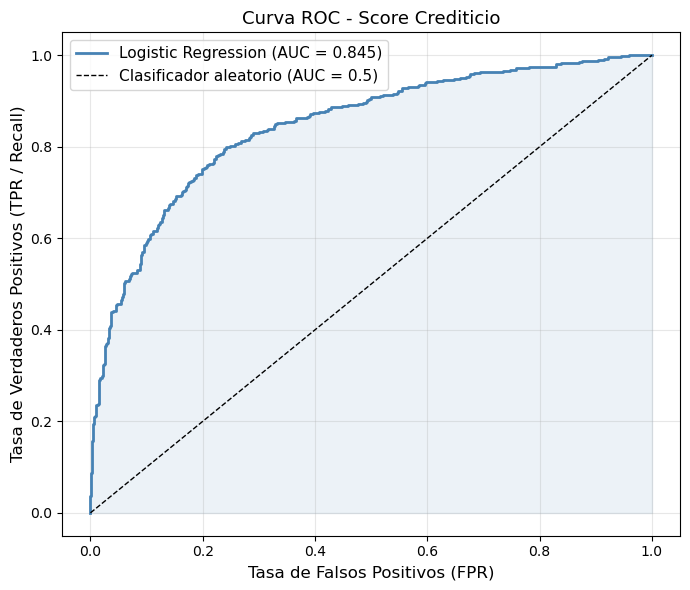

AUC: 0.8452


In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_c, y_prob_c)
auc_score = roc_auc_score(y_test_c, y_prob_c)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"Logistic Regression (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Clasificador aleatorio (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.1, color="steelblue")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR / Recall)", fontsize=12)
ax.set_title("Curva ROC - Score Crediticio", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f}")

#### **3.8 El efecto del umbral de clasificación**

Por defecto, sklearn clasifica como positivo ($\hat{y}=1$) cuando $P(\text{default}) > 0.5$. Pero podemos cambiar este umbral:

- **Umbral bajo (ej. 0.3):** clasificamos más solicitantes como default -> más Recall, menos Precision.
- **Umbral alto (ej. 0.7):** solo clasificamos como default a los casos muy claros -> más Precision, menos Recall.

En un banco conservador (que prefiere rechazar dudosos), el umbral sería **bajo**. En uno agresivo (que quiere maximizar aprobaciones), sería **alto**.

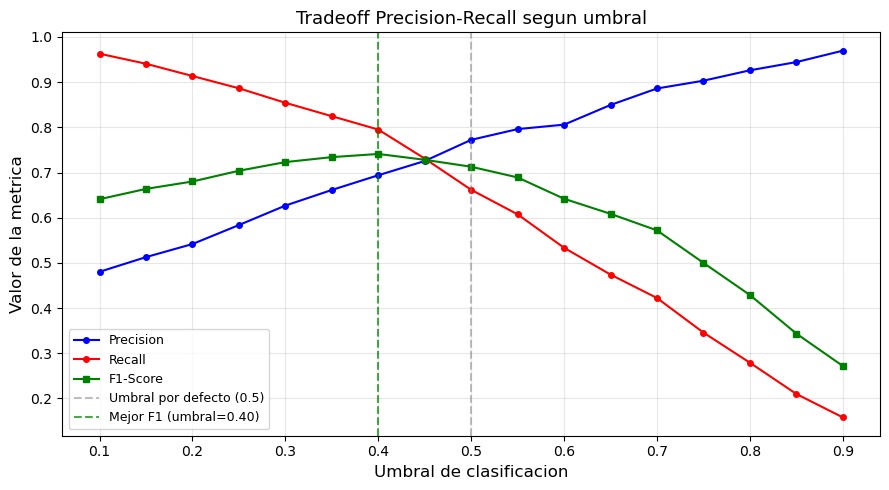

Umbral que maximiza F1: 0.40


In [ ]:
# Efecto del umbral sobre Precision y Recall
umbrales = np.arange(0.1, 0.91, 0.05)
precision_list = []
recall_list = []
f1_list = []

for u in umbrales:
    y_pred_u = (y_prob_c >= u).astype(int)
    precision_list.append(precision_score(y_test_c, y_pred_u, zero_division=0))
    recall_list.append(recall_score(y_test_c, y_pred_u, zero_division=0))
    f1_list.append(f1_score(y_test_c, y_pred_u, zero_division=0))

# Umbral que maximiza F1
best_threshold = umbrales[np.argmax(f1_list)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(umbrales, precision_list, "b-o", markersize=4, label="Precision")
ax.plot(umbrales, recall_list, "r-o", markersize=4, label="Recall")
ax.plot(umbrales, f1_list, "g-s", markersize=4, label="F1-Score")
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral por defecto (0.5)")
ax.axvline(x=best_threshold, color="green", linestyle="--", alpha=0.7, label=f"Mejor F1 (umbral={best_threshold:.2f})")
ax.set_xlabel("Umbral de clasificacion", fontsize=12)
ax.set_ylabel("Valor de la metrica", fontsize=12)
ax.set_title("Tradeoff Precision-Recall segun umbral", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Umbral que maximiza F1: {best_threshold:.2f}")

#### **3.9 Comparación de clasificadores**

Comparemos la Regresión Logística con un Árbol de Decisión (que vimos en la Ayudantía 3):

In [ ]:
# Arbol de decision como clasificador alternativo
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train_c_sc, y_train_c)
y_pred_tree = tree_clf.predict(X_test_c_sc)
y_prob_tree = tree_clf.predict_proba(X_test_c_sc)[:, 1]

# Comparamos metricas
modelos_clf = {
    "Logistic Regression": (y_pred_c, y_prob_c),
    "Decision Tree (d=5)": (y_pred_tree, y_prob_tree),
}

print(f"{'Modelo':<24} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")


for nombre, (y_p, y_pr) in modelos_clf.items():
    a = accuracy_score(y_test_c, y_p)
    p = precision_score(y_test_c, y_p)
    r = recall_score(y_test_c, y_p)
    f = f1_score(y_test_c, y_p)
    auc = roc_auc_score(y_test_c, y_pr)
    print(f"{nombre:<24} {a:>10.4f} {p:>10.4f} {r:>10.4f} {f:>10.4f} {auc:>10.4f}")

Modelo                     Accuracy  Precision     Recall         F1        AUC
Logistic Regression          0.7840     0.7723     0.6617     0.7128     0.8452
Decision Tree (d=5)          0.7720     0.8195     0.5605     0.6657     0.8019


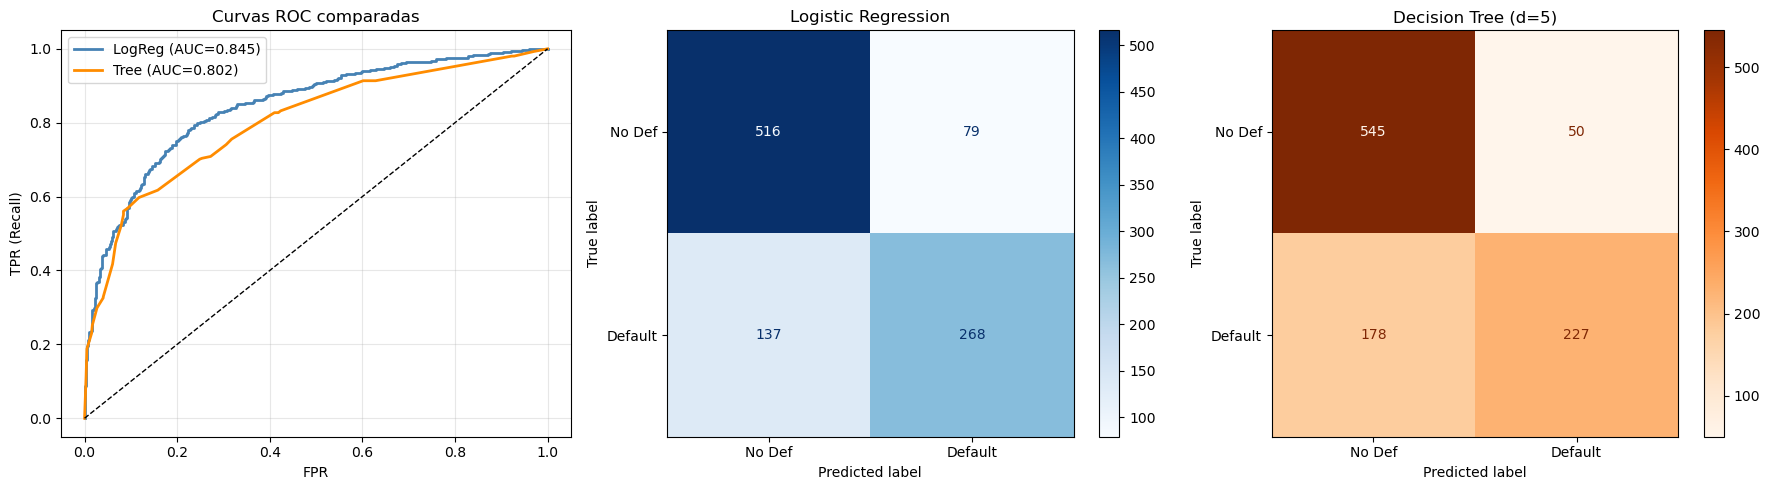

In [ ]:
# Curvas ROC comparadas
fpr_tree, tpr_tree, _ = roc_curve(y_test_c, y_prob_tree)
auc_tree = roc_auc_score(y_test_c, y_prob_tree)

# Recuerden que si el gráfico se ve muy grande, pueden ajustar el figsize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC comparativa
axes[0].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"LogReg (AUC={auc_score:.3f})")
axes[0].plot(fpr_tree, tpr_tree, color="darkorange", linewidth=2, label=f"Tree (AUC={auc_tree:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR (Recall)")
axes[0].set_title("Curvas ROC comparadas")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Matrices de confusion lado a lado
cm_log = confusion_matrix(y_test_c, y_pred_c)
cm_tree = confusion_matrix(y_test_c, y_pred_tree)

ConfusionMatrixDisplay(cm_log, display_labels=["No Def", "Default"]).plot(ax=axes[1], cmap="Blues", values_format="d")
axes[1].set_title("Logistic Regression")

ConfusionMatrixDisplay(cm_tree, display_labels=["No Def", "Default"]).plot(ax=axes[2], cmap="Oranges", values_format="d")
axes[2].set_title("Decision Tree (d=5)")

plt.tight_layout()
plt.show()

---

## **Resumen y Takeaways**

**1. Generalización:**
- Un buen modelo no es el que mejor ajusta los datos de entrenamiento, sino el que mejor predice datos nuevos o fuera del training sample.
- La diferencia entre el error del train y el error de test sample suele ser una buena referencia para detectar overfitting.
- Cross Validation nos da una estimación honesta del error de generalización.

**2. Regularización:**
- Ridge (L2) disminuye todos los coeficientes, útil cuando todas las variables aportan algo.
- Lasso (L1) lleva coeficientes a cero, útil para seleccionar qué variables importan.
- ElasticNet combina ambas propiedades.
- Siempre estandarizar antes de regularizar.
- Elegir $\lambda$ con Cross Validation.

**3. Métricas de clasificación:**
- Accuracy puede ser engañoso cuando existe desbalance de clases (como default crediticio, fraude, crisis).
- Precision indica: "de los que predije como positivos, cuántos lo son realmente?"
- Recall responde: "de los positivos reales, cuántos detecté?"
- F1 es un compromiso entre ambas.
- La curva ROC y el AUC permiten comparar modelos sin depender de un umbral específico.
- La elección de umbral depende del **costo relativo de los errores**, que es una decisión económica.

> *La métrica correcta depende del problema. Un médico que busca detectar cancer debería maximizar Recall ya que las consecuencias de no detectarlo cuando existe son mucho peores que decir que hay cancer cuando no lo hay; una fintech que quiere minimizar rechazos innecesarios debería cuidar la Precision.*

**Tabla de referencia rapida:**

| Concepto | Idea clave | Herramienta en sklearn |
|---|---|---|
| Overfitting | RMSE train << RMSE test | Curva de error, `cross_val_score` |
| Underfitting | RMSE alto en ambos | Aumentar complejidad |
| Ridge (L2) | Encoge coeficientes, mantiene todos | `Ridge`, `RidgeCV` |
| Lasso (L1) | Encoge y puede eliminar coeficientes | `Lasso`, `LassoCV` |
| ElasticNet | Combinación L1 + L2 | `ElasticNet` |
| Confusion Matrix | Desglosa TP, FP, FN, TN | `confusion_matrix` |
| Precision | De los predichos +, cuántos lo eran? | `precision_score` |
| Recall | De los reales +, cuántos detecté? | `recall_score` |
| F1-Score | Promedio armónico Precision-Recall | `f1_score` |
| ROC / AUC | Evaluación global del clasificador | `roc_curve`, `roc_auc_score` |
| Umbral | Ajustar según costos relativos de FP vs FN | `predict_proba` + threshold |